In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/nandini5002/chandrayan-train-1/pytorch/default/1/best_final.pt
/kaggle/input/datasets/nandini5002/test-images/test/img_000252.jpg
/kaggle/input/datasets/nandini5002/test-images/test/ch2_ohr_ncp_20220713T1223352508_b_brw_d32_166.jpg
/kaggle/input/datasets/nandini5002/test-images/test/ch2_ohr_ncp_20220713T1223352508_b_brw_d32_173.jpg
/kaggle/input/datasets/nandini5002/test-images/test/img_000261.jpg
/kaggle/input/datasets/nandini5002/test-images/test/img_000059.jpg
/kaggle/input/datasets/nandini5002/test-images/test/ch2_ohr_ncp_20210405T1606536730_b_brw_d18_691.jpg
/kaggle/input/datasets/nandini5002/test-images/test/img_000062.jpg
/kaggle/input/datasets/nandini5002/test-images/test/ch2_ohr_ncp_20220713T1223352463_b_brw_d32_303.jpg
/kaggle/input/datasets/nandini5002/test-images/test/ch2_ohr_ncp_20210405T1606537227_b_brw_d18_738.jpg
/kaggle/input/datasets/nandini5002/test-images/test/ch2_ohr_ncp_20220713T1223352508_b_brw_d32_168.jpg
/kaggle/input/datasets/nandini5002/t

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.9 MB/s eta 0:00:00


In [3]:

from ultralytics import YOLO
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
MODEL_PATH  = "/kaggle/input/models/nandini5002/chandrayan-train-1/pytorch/default/1/best_final.pt"
CONF        = 0.25        # lower = catches more small craters
IOU         = 0.45          # NMS threshold
IMGSZ       = 640
 
CLASS_NAMES  = ["crater_small", "crater_medium", "crater_large"]
CLASS_COLORS = {
    "crater_small" : "#378ADD",   # blue
    "crater_medium": "#EF9F27",   # amber
    "crater_large" : "#D85A30",   # coral
}
 
model = YOLO(MODEL_PATH)

In [5]:
# Path to your test images folder
IMAGE_PATH = "/kaggle/input/datasets/nandini5002/test-images/test"   # <-- change this

# Run inference
results_list = model.predict(
    source=IMAGE_PATH,
    conf=CONF,
    iou=IOU,
    imgsz=IMGSZ,
    stream=False  # returns list instead of generator
)


image 1/128 /kaggle/input/datasets/nandini5002/test-images/test/ch2_ohr_ncp_20210401T2357376656_b_brw_d18_433.jpg: 640x640 39 crater_smalls, 1 crater_large, 410.6ms
image 2/128 /kaggle/input/datasets/nandini5002/test-images/test/ch2_ohr_ncp_20210402T0155096873_b_brw_d18_113.jpg: 640x640 44 crater_smalls, 2 crater_mediums, 3 crater_larges, 268.4ms
image 3/128 /kaggle/input/datasets/nandini5002/test-images/test/ch2_ohr_ncp_20210402T0155096873_b_brw_d18_118.jpg: 640x640 34 crater_smalls, 1 crater_large, 247.5ms
image 4/128 /kaggle/input/datasets/nandini5002/test-images/test/ch2_ohr_ncp_20210402T0155096873_b_brw_d18_128.jpg: 640x640 13 crater_smalls, 1 crater_medium, 248.2ms
image 5/128 /kaggle/input/datasets/nandini5002/test-images/test/ch2_ohr_ncp_20210402T0155096873_b_brw_d18_131.jpg: 640x640 24 crater_smalls, 4 crater_mediums, 2 crater_larges, 250.4ms
image 6/128 /kaggle/input/datasets/nandini5002/test-images/test/ch2_ohr_ncp_20210402T0155096873_b_brw_d18_132.jpg: 640x640 43 crater_sm

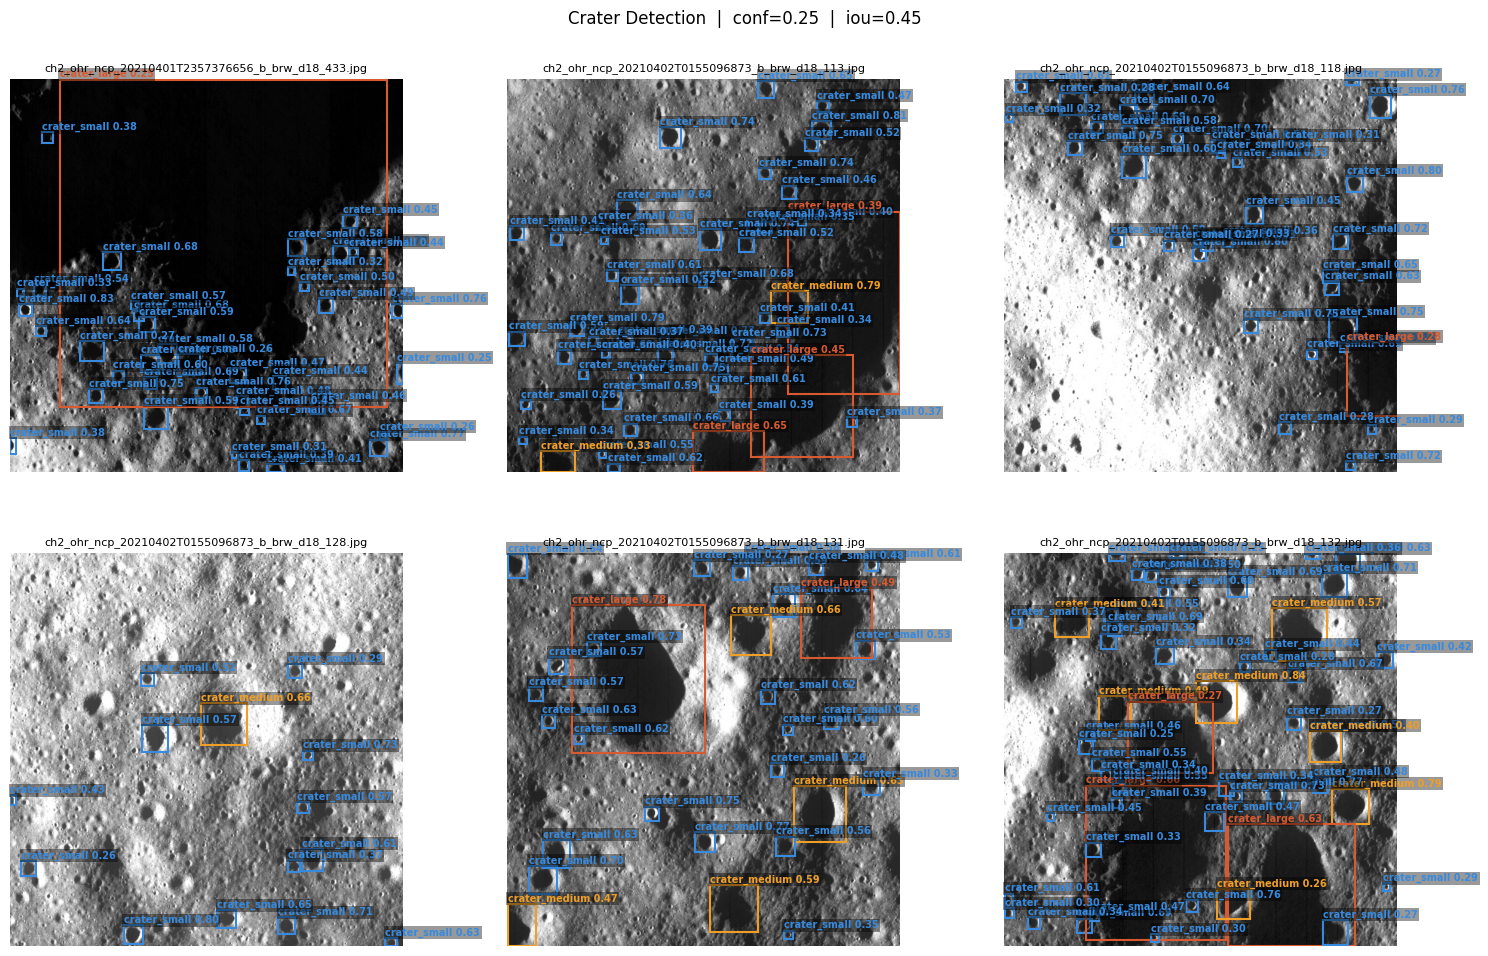

✅ Grid saved → /kaggle/working/inference_grid.png


In [6]:
def visualize_predictions(results_list, n=6, cols=3):
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    axes = axes.flatten()
 
    for idx, result in enumerate(results_list[:n]):
        img_bgr = result.orig_img
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax = axes[idx]
        ax.imshow(img_rgb)
 
        if result.boxes is not None and len(result.boxes):
            for box in result.boxes:
                cls_id = int(box.cls.item())
                conf   = float(box.conf.item())
                name   = CLASS_NAMES[cls_id]
                color  = CLASS_COLORS[name]
 
                # box.xyxy → [x1, y1, x2, y2]
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                w, h = x2 - x1, y2 - y1
 
                rect = patches.Rectangle(
                    (x1, y1), w, h,
                    linewidth=1.5,
                    edgecolor=color,
                    facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(
                    x1, y1 - 4,
                    f"{name} {conf:.2f}",
                    color=color,
                    fontsize=7,
                    fontweight="bold",
                    bbox=dict(facecolor="black", alpha=0.4, pad=1, edgecolor="none")
                )
 
        ax.set_title(Path(result.path).name, fontsize=8)
        ax.axis("off")
 
    # hide unused axes
    for ax in axes[n:]:
        ax.axis("off")
 
    plt.suptitle(f"Crater Detection  |  conf={CONF}  |  iou={IOU}", fontsize=12)
    plt.tight_layout()
    plt.savefig("/kaggle/working/inference_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Grid saved → /kaggle/working/inference_grid.png")
 
 
visualize_predictions(results_list, n=6, cols=3)